## O problema está no modelo ou nos dados?

**Data:** 19/03/2026

**Objetivo:**  Investigar por que um modelo de regressão linear falha ao prever o preço de roupas usando variáveis categóricas.
- Hipótese: O baixo desempenho não é causado pelo modelo, mas pela ausência de relação estatística entre as variáveis explicativas e o preço.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [31]:
df = pd.read_csv('data/clothes_price_prediction_data.csv')
df.head(5)

,Brand,Category,Color,Size,Material,Price
0,New Balance,Dress,White,XS,Nylon,182
1,New Balance,Jeans,Black,XS,Silk,57
2,Under Armour,Dress,Red,M,Wool,127
3,Nike,Shoes,Green,M,Cotton,77
4,Adidas,Sweater,White,M,Nylon,113


In [35]:
df.describe()

,Price
count,1000.000000
mean,106.289000
std,53.695444
min,10.000000
25%,59.750000
50%,108.000000
75%,150.000000
max,199.000000


In [15]:
categorical_cols = ['Brand', 'Category', 'Color', 'Size', 'Material']

encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

encoded_array = encoder.fit_transform(df[categorical_cols])

In [16]:
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(categorical_cols)
)

encoded_df['Price'] = df['Price']

encoded_df.info()
encoded_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Brand_New Balance   1000 non-null   float64
 1   Brand_Nike          1000 non-null   float64
 2   Brand_Puma          1000 non-null   float64
 3   Brand_Reebok        1000 non-null   float64
 4   Brand_Under Armour  1000 non-null   float64
 5   Category_Jacket     1000 non-null   float64
 6   Category_Jeans      1000 non-null   float64
 7   Category_Shoes      1000 non-null   float64
 8   Category_Sweater    1000 non-null   float64
 9   Category_T-shirt    1000 non-null   float64
 10  Color_Blue          1000 non-null   float64
 11  Color_Green         1000 non-null   float64
 12  Color_Red           1000 non-null   float64
 13  Color_White         1000 non-null   float64
 14  Color_Yellow        1000 non-null   float64
 15  Size_M              1000 non-null   float64
 16  Size_S            

,Brand_New Balance,Brand_Nike,Brand_Puma,Brand_Reebok,Brand_Under Armour,Category_Jacket,Category_Jeans,Category_Shoes,Category_Sweater,Category_T-shirt,...,Size_S,Size_XL,Size_XS,Size_XXL,Material_Denim,Material_Nylon,Material_Polyester,Material_Silk,Material_Wool,Price
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,182
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,57
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,127
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,113


In [17]:
y = encoded_df['Price']

X = encoded_df.drop(columns=['Price'])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred = model.predict(X_test)

In [41]:
df_resultado = pd.DataFrame({
    'Nota Real (Gabarito)': y_test.head(10),
    'Previsto Reg. Linear': y_pred[:10].round(1),
})
display(df_resultado)

,Nota Real (Gabarito),Previsto Reg. Linear
521,101,108.6
737,164,133.1
740,58,113.3
660,82,103.5
411,177,106.3
678,79,92.9
626,38,105.6
513,118,100.0
859,157,103.7
136,68,101.0


In [20]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 46.32198766323365
RMSE: 54.12907961711744
R²: 0.00018444470709788607


O R² próximo de zero indica que o modelo não consegue explicar a variação do preço.

#### Métricas de regressão: MAE, RMSE e R²

Quando fazemos regressão, queremos responder:  **quão próximas as previsões estão dos valores reais?**  
Cada métrica avalia o erro de uma forma diferente.

---

### MAE — Mean Absolute Error
Mede o **erro médio absoluto** entre valores reais e previstos.

**Interpretação:**  
O modelo erra, em média, **X unidades de preço** por previsão.

- Fácil de interpretar  
- Mesma unidade do problema  
- Bom para comunicar erro para humanos

---

### RMSE — Root Mean Squared Error
Mede o erro médio **penalizando erros grandes**.

**Interpretação:**  
Indica se o modelo comete previsões muito distantes do valor real.

- Erros grandes têm maior impacto  
- Se `RMSE > MAE`, existem erros grandes no modelo  
- Usado quando grandes erros são mais críticos (ex: finanças)

---

### R² — Coeficiente de Determinação
Mede quanto da variação dos dados é explicada pelo modelo.

**Interpretação:**  
O modelo explica aproximadamente **X% da variação do preço**.

- `R² = 1` → perfeito  
- `R² = 0` → equivalente a prever a média  
- `R² < 0` → pior que prever a média

---

### Interpretação conjunta

- **MAE** → tamanho médio do erro  
- **RMSE** → presença de erros grandes  
- **R²** → existência de relação preditiva nos dados

In [21]:
coeficientes = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': model.coef_
}).sort_values(by='Coeficiente', ascending=False)

coeficientes

,Feature,Coeficiente
13,Color_White,10.720969
0,Brand_New Balance,8.466657
19,Size_XXL,7.436625
24,Material_Wool,6.935871
18,Size_XS,6.596292
20,Material_Denim,6.079158
21,Material_Nylon,5.688963
16,Size_S,3.283692
22,Material_Polyester,2.510138
14,Color_Yellow,2.134600


In [ ]:
categorical_cols = ['Brand', 'Category', 'Color', 'Size', 'Material']

encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

encoded_array = encoder.fit_transform(df[categorical_cols])

### identificando problema

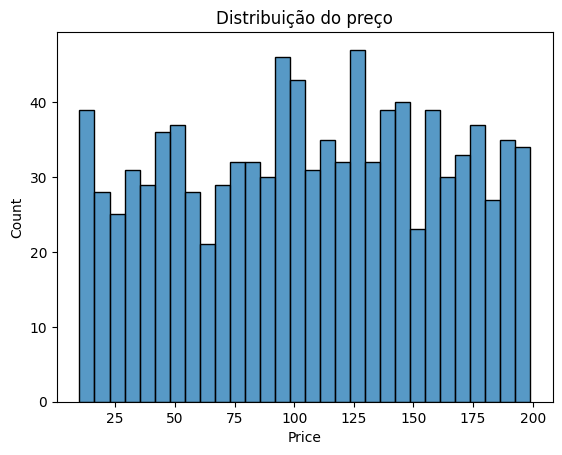

In [36]:
sns.histplot(df['Price'], bins=30)
plt.title("Distribuição do preço")
plt.show()

In [37]:
df.groupby('Brand')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Brand,,,,,,,,
Adidas,166.0,104.054217,53.211443,10.0,56.25,104.0,148.00,198.0
New Balance,164.0,115.457317,49.873503,14.0,76.50,122.0,151.25,198.0
Nike,165.0,101.909091,53.410835,11.0,57.00,101.0,143.00,199.0
Puma,168.0,106.136905,53.958170,10.0,57.75,104.5,155.50,199.0
Reebok,158.0,106.493671,53.729773,10.0,62.75,107.5,150.00,198.0
Under Armour,179.0,103.960894,57.162332,10.0,54.50,104.0,150.00,198.0


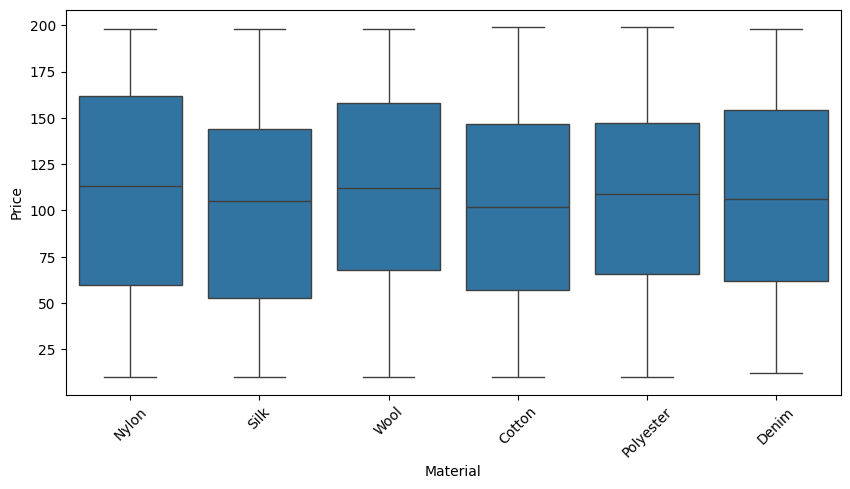

In [39]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Material', y='Price')
plt.xticks(rotation=45)
plt.show()

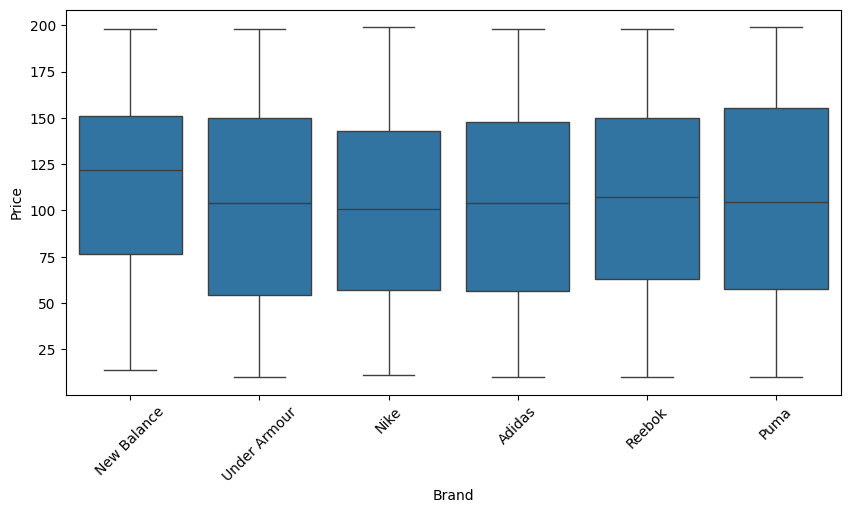

In [38]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Brand', y='Price')
plt.xticks(rotation=45)
plt.show()

A variância dentro das categorias é muito maior que a variância entre categorias.

Logo, conhecer Brand, Color ou Material não reduz a incerteza sobre o preço.

Às vezes o problema de um modelo não está no algoritmo, mas nos próprios dados.

Mesmo usando um modelo correto e bem configurado, ele só consegue aprender padrões que realmente existem. No nosso caso, a variação de preço dentro de cada categoria é muito maior do que a diferença média entre as categorias. Ou seja, roupas da mesma marca, cor ou material apresentam preços muito diferentes entre si.

Isso significa que conhecer informações como *Brand*, *Color* ou *Material* quase não ajuda a reduzir a incerteza sobre o preço. Para o modelo, essas variáveis não trazem informação suficiente para fazer boas previsões.

Em termos simples: o modelo pode estar funcionando perfeitamente, mas se os dados não têm relação real com o que queremos prever, o resultado ainda será ruim. Machine Learning não cria informação — ele apenas encontra padrões que já existem nos dados.